# FlameIQ Synthetic Refill-Cycle Data Validation

## Objective

This notebook validates the synthetic refill-cycle dataset created for the FlameIQ refill prediction proof of concept.

Because FlameIQ did not yet have longitudinal production refill history before the hackathon, synthetic refill cycles were generated using household profile, refill quantity, cooking behaviour, refill history and seasonal assumptions.

The purpose of this notebook is to confirm that the generated data behaves logically before using it for machine-learning model development.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
BASE_DIR = Path.cwd().resolve()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "refill_cycles_model.csv"
)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

df.head()

Shape: (8368, 16)


,user_id,refill_cycle_id,refill_date,cylinder_size_kg,refill_quantity_kg,household_size,meals_per_day,cooking_days_per_week,lpg_primary_fuel,usage_change,festive_period,refill_month,previous_cycle_days,average_previous_cycle_days,number_previous_cycles,actual_cycle_days
0,USR_20000,USR_20000_C01,2025-03-06,12.5,11.52,6,3,6,0,normal,0,3,NaN,NaN,0,40
1,USR_20000,USR_20000_C02,2025-04-15,12.5,9.37,6,3,6,0,normal,0,4,40.0,40.000000,1,34
2,USR_20000,USR_20000_C03,2025-05-19,12.5,11.94,6,3,6,0,normal,0,5,34.0,37.000000,2,36
3,USR_20000,USR_20000_C04,2025-06-24,12.5,9.65,6,3,6,0,more,0,6,36.0,36.666667,3,28
4,USR_20000,USR_20000_C05,2025-07-22,12.5,12.50,6,3,6,0,less,0,7,28.0,34.500000,4,55


## 1. Target Distribution

The prediction target is `actual_cycle_days`, representing the total number of days between one refill and the next.

A useful synthetic dataset should contain variation across users rather than concentrating heavily at an artificial minimum or maximum.

In [3]:
df["actual_cycle_days"].describe()

count    8368.000000
mean       30.961401
std        13.004318
min         6.000000
25%        21.000000
50%        29.000000
75%        39.000000
max        75.000000
Name: actual_cycle_days, dtype: float64

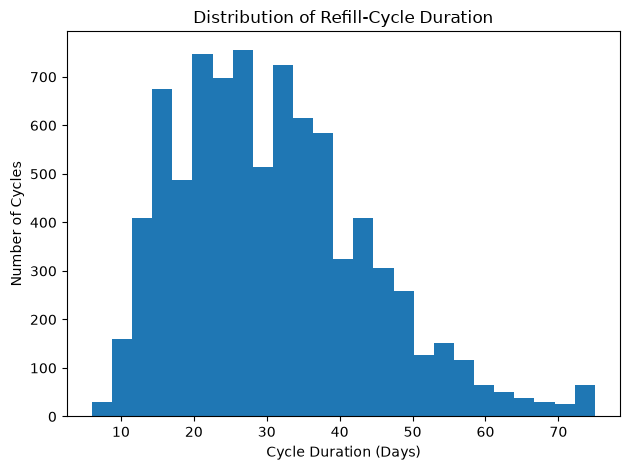

In [4]:
plt.hist(
    df["actual_cycle_days"],
    bins=25
)

plt.title("Distribution of Refill-Cycle Duration")
plt.xlabel("Cycle Duration (Days)")
plt.ylabel("Number of Cycles")
plt.tight_layout()
plt.show()

The generated refill-cycle distribution has a median of approximately 29 days and a mean of approximately 31 days.

The range extends from 6 to 75 days, allowing short and long refill cycles without forcing most observations against an artificial upper boundary.

In [5]:
pct_min = (
    df["actual_cycle_days"] <= 6
).mean() * 100

pct_max = (
    df["actual_cycle_days"] >= 75
).mean() * 100

print(f"At minimum 6 days: {pct_min:.2f}%")
print(f"At maximum 75 days: {pct_max:.2f}%")

At minimum 6 days: 0.07%
At maximum 75 days: 0.63%


In [6]:
df.loc[
    df["actual_cycle_days"] == 75,
    "cylinder_size_kg"
].value_counts()

cylinder_size_kg
12.5    53
Name: count, dtype: int64

Only 0.63% of refill cycles reach the 75-day upper bound. This indicates that the synthetic target is not materially distorted by the maximum-duration constraint.

In [7]:
df.groupby(
    "cylinder_size_kg"
)["actual_cycle_days"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
cylinder_size_kg,,,,,,
6.0,3113,20.269515,19.0,6.682789,6,54
12.5,5255,37.295147,36.0,11.619058,11,75


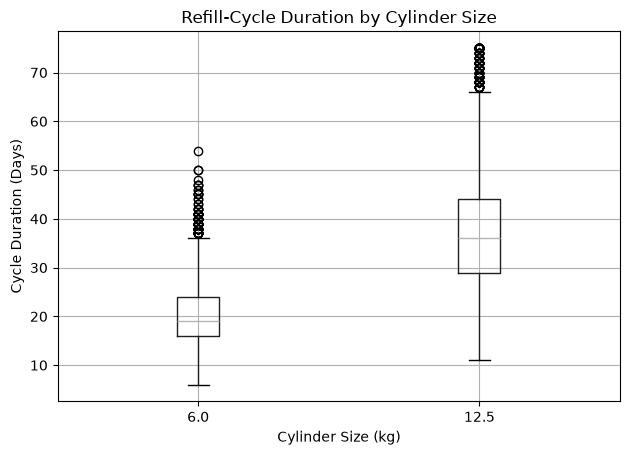

In [8]:
df.boxplot(
    column="actual_cycle_days",
    by="cylinder_size_kg"
)

plt.title("Refill-Cycle Duration by Cylinder Size")
plt.suptitle("")
plt.xlabel("Cylinder Size (kg)")
plt.ylabel("Cycle Duration (Days)")
plt.tight_layout()
plt.show()

## 2. Relationship Between Cylinder Size and Refill Duration

Larger cylinders generally support longer refill cycles because they contain more LPG.

However, cylinder size should not be interpreted independently of household size, refill quantity and cooking behaviour.

In [9]:
for size in sorted(
    df["cylinder_size_kg"].unique()
):

    subset = df[
        df["cylinder_size_kg"] == size
    ]

    print(
        f"\nCylinder size: {size} kg"
    )

    cols = [
        "household_size",
        "meals_per_day",
        "refill_quantity_kg",
        "actual_cycle_days",
    ]

    print(
        subset[cols]
        .corr(numeric_only=True)[
            "actual_cycle_days"
        ]
        .sort_values(
            ascending=False
        )
    )


Cylinder size: 6.0 kg
actual_cycle_days     1.000000
refill_quantity_kg    0.384306
meals_per_day        -0.309029
household_size       -0.387807
Name: actual_cycle_days, dtype: float64

Cylinder size: 12.5 kg
actual_cycle_days     1.000000
refill_quantity_kg    0.389784
meals_per_day        -0.255892
household_size       -0.365558
Name: actual_cycle_days, dtype: float64


Within each cylinder-size group, the relationships behave as expected:

- Larger refill quantities are associated with longer refill cycles.
- Larger households are associated with shorter refill cycles.
- More meals cooked per day are associated with shorter refill cycles.

This confirms that household usage intensity is represented logically rather than being masked by differences in cylinder capacity.

In [10]:
df["usage_change"].value_counts()

usage_change
normal    6829
more       869
less       670
Name: count, dtype: int64

In [11]:
df.groupby(
    "usage_change"
)["actual_cycle_days"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
usage_change,,,
less,670,37.470149,36.0
more,869,24.271577,23.0
normal,6829,31.174110,30.0


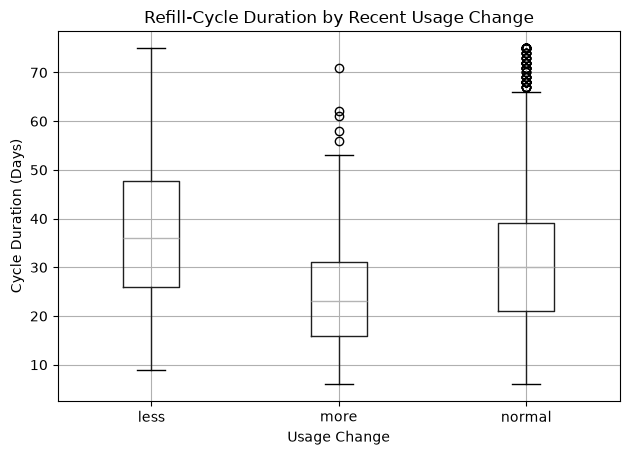

In [12]:
df.boxplot(
    column="actual_cycle_days",
    by="usage_change"
)

plt.title(
    "Refill-Cycle Duration by Recent Usage Change"
)
plt.suptitle("")
plt.xlabel("Usage Change")
plt.ylabel("Cycle Duration (Days)")
plt.tight_layout()
plt.show()

## 3. Recent Cooking Behaviour

The `usage_change` variable captures whether the household reports cooking:

- normally,
- more than usual, or
- less than usual.

The generated data behaves consistently with the intended assumption. Households cooking more than usual have shorter refill cycles, while households cooking less have longer refill cycles.

In [13]:
numeric_features = [
    "cylinder_size_kg",
    "refill_quantity_kg",
    "household_size",
    "meals_per_day",
    "cooking_days_per_week",
    "lpg_primary_fuel",
    "festive_period",
    "previous_cycle_days",
    "average_previous_cycle_days",
    "number_previous_cycles",
    "actual_cycle_days",
]

correlations = (
    df[numeric_features]
    .corr(numeric_only=True)[
        "actual_cycle_days"
    ]
    .sort_values(
        ascending=False
    )
)

correlations

actual_cycle_days              1.000000
average_previous_cycle_days    0.844132
previous_cycle_days            0.788721
refill_quantity_kg             0.699429
cylinder_size_kg               0.632843
festive_period                 0.051942
household_size                 0.024498
number_previous_cycles        -0.008290
cooking_days_per_week         -0.046720
meals_per_day                 -0.162615
lpg_primary_fuel              -0.315801
Name: actual_cycle_days, dtype: float64

## 4. Historical Refill Behaviour

Historical refill duration is one of the strongest signals in the dataset.

`average_previous_cycle_days` and `previous_cycle_days` show strong positive relationships with the current refill-cycle duration.

This supports the use of a personalised prediction pathway once a user has accumulated refill history.

In [14]:
cold_start = df[
    df["number_previous_cycles"] == 0
]

returning = df[
    df["number_previous_cycles"] > 0
]

print(
    "Cold-start rows:",
    len(cold_start)
)

print(
    "Returning-user rows:",
    len(returning)
)

print("\nCold-start target:")
print(
    cold_start[
        "actual_cycle_days"
    ].describe()
)

print("\nReturning-user target:")
print(
    returning[
        "actual_cycle_days"
    ].describe()
)

Cold-start rows: 1257
Returning-user rows: 7111

Cold-start target:
count    1257.00000
mean       30.78043
std        12.75521
min         6.00000
25%        21.00000
50%        29.00000
75%        38.00000
max        75.00000
Name: actual_cycle_days, dtype: float64

Returning-user target:
count    7111.000000
mean       30.993391
std        13.048480
min         6.000000
25%        21.000000
50%        29.000000
75%        39.000000
max        75.000000
Name: actual_cycle_days, dtype: float64


The dataset contains 1,257 cold-start observations and 7,111 returning-user observations.

The target distributions are similar across both groups. The key difference is the availability of refill-history features for returning users.

This supports training separate cold-start and personalised prediction pathways rather than imputing artificial history for new users.

In [15]:
print(
    "Duplicate cycle IDs:",
    df["refill_cycle_id"]
    .duplicated()
    .sum()
)

Duplicate cycle IDs: 0


In [16]:
df["refill_date"] = pd.to_datetime(
    df["refill_date"]
)

bad_sequences = 0

for _, group in (
    df.sort_values(
        ["user_id", "refill_date"]
    )
    .groupby("user_id")
):

    if not group[
        "refill_date"
    ].is_monotonic_increasing:

        bad_sequences += 1

print(
    "Users with invalid date sequence:",
    bad_sequences
)

Users with invalid date sequence: 0


## Validation Conclusion

The synthetic refill-cycle dataset passes the main structural and behavioural validation checks required for the FlameIQ proof of concept.

Key findings include:

- 8,368 refill cycles across 1,257 household users.
- Only 0.63% of observations reach the 75-day upper bound.
- Larger refill quantities are associated with longer refill cycles.
- Larger households and higher meal frequency shorten refill cycles within the same cylinder size.
- Recent increases in cooking activity shorten refill cycles, while reduced cooking extends them.
- Historical refill duration provides strong personalised predictive signal.
- Cold-start and returning-user cases are clearly distinguishable.
- No duplicate refill-cycle IDs were found.
- All user refill dates follow valid chronological sequences.

The dataset is therefore suitable for proof-of-concept model experimentation.

Performance results obtained from this dataset should be reported explicitly as synthetic proof-of-concept results and should not be represented as production accuracy.